In [277]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")
print(path)

/kaggle/input/datasets/salader/dogsvscats


In [278]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/salader/dogsvscats"):
    print(root)

/kaggle/input/datasets/salader/dogsvscats
/kaggle/input/datasets/salader/dogsvscats/test
/kaggle/input/datasets/salader/dogsvscats/test/dogs
/kaggle/input/datasets/salader/dogsvscats/test/cats
/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/train/dogs
/kaggle/input/datasets/salader/dogsvscats/train/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/cats


In [279]:
# import important libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,Rescaling

In [280]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32,
    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/test",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.


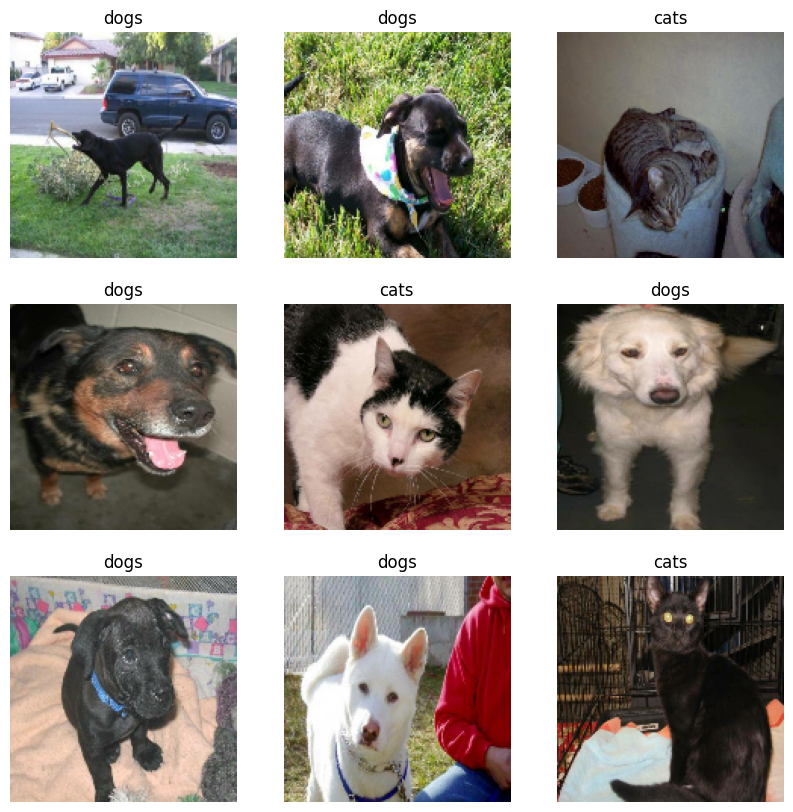

In [281]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [282]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [283]:
# data augmentation
# 15/360 tells Keras to rotate randomly within a range of -15 to +15 degrees
data_augmentation = Sequential([
    RandomRotation(15 / 360),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomFlip("horizontal")
])

# build architecture

model = Sequential([
    # Step A: Define the explicit image input size
    InputLayer(input_shape=(150, 150, 3)),
    Rescaling(1./255),
    # Step B: Apply GPU-accelerated transformations (skipped automatically during validation)
    data_augmentation,
    
    # First Convolution Block
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Second Convolution Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Third Convolution Block
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Fourth Convolution Block
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Flatten & Fully Connected Classifier Block
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Ideal output layer for binary classification (Cats vs Dogs)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_23 (Sequential)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,634,881 (13.87 MB)

 Trainable params: 3,633,921 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [284]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [285]:
model.compile( optimizer='adam' ,loss='binary_crossentropy',metrics=["accuracy"])

In [286]:
# train model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
model_history=model.fit(train_ds, epochs=15, validation_data=val_ds,callbacks=[early_stopping,checkpoint])

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.5900 - loss: 0.8982 - val_accuracy: 0.4493 - val_loss: 0.8281
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.6767 - loss: 0.5980 - val_accuracy: 0.7582 - val_loss: 0.4685
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.7378 - loss: 0.5292 - val_accuracy: 0.8755 - val_loss: 0.3651
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7876 - loss: 0.4550 - val_accuracy: 0.9093 - val_loss: 0.2759
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.8169 - loss: 0.4005 - val_accuracy: 0.4173 - val_loss: 0.8983
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.8514 - loss: 0.3441 - val_accuracy: 0.9427 - val_loss: 0.2030
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.8692 - loss: 0.3046 - val_accuracy: 0.9515 - val_loss: 0.1493
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.8855 - loss: 0.2729 - 

In [287]:
model.save("cats_dogs_model.keras")

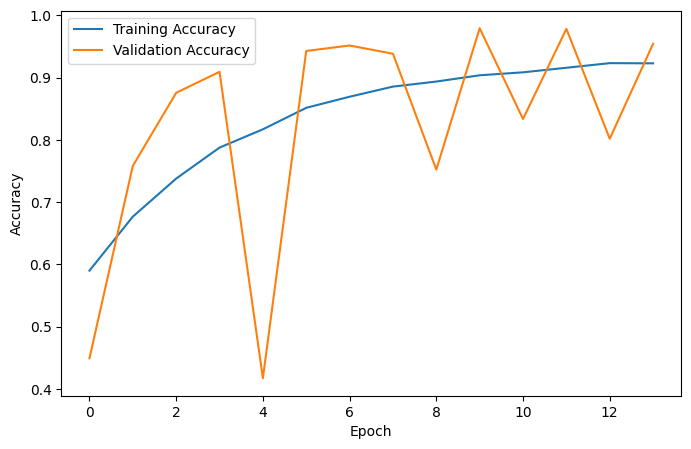

In [288]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['accuracy'],label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

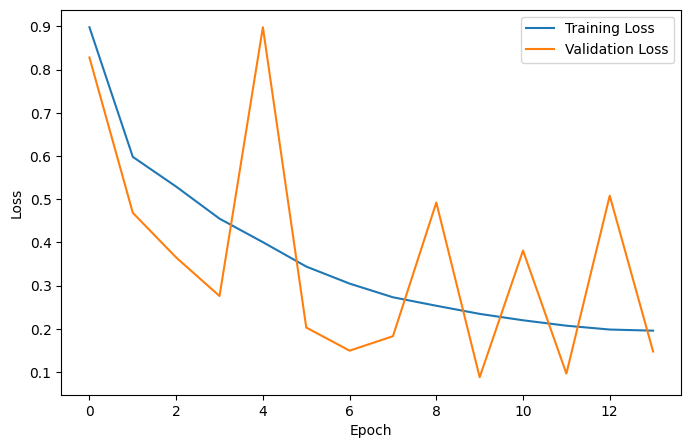

In [289]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['loss'],label='Training Loss')
plt.plot(model_history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [290]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8644 - loss: 0.3154
Test Loss: 0.31544429063796997
Test Accuracy: 0.8644000291824341


In [291]:
# predict output
class_names = ["cat", "dog"]
y_true = []
X=[]
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    X.extend(images)
y_true = np.array(y_true)
print("Actual :",class_names[y_true[1]])
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("Predicted :",class_names[y_pred[1]])

Actual : cat
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
Predicted : cat


In [292]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.77      0.85      2500
           1       0.81      0.96      0.88      2500

    accuracy                           0.86      5000
   macro avg       0.88      0.86      0.86      5000
weighted avg       0.88      0.86      0.86      5000



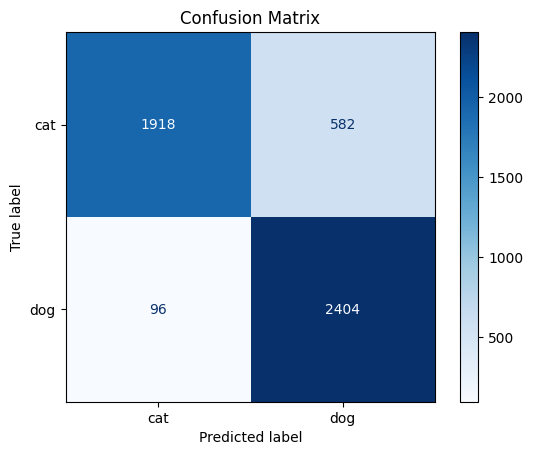

In [293]:
# print confusion matrix

ConfusionMatrixDisplay.from_predictions(
   y_true,y_pred,
    display_labels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

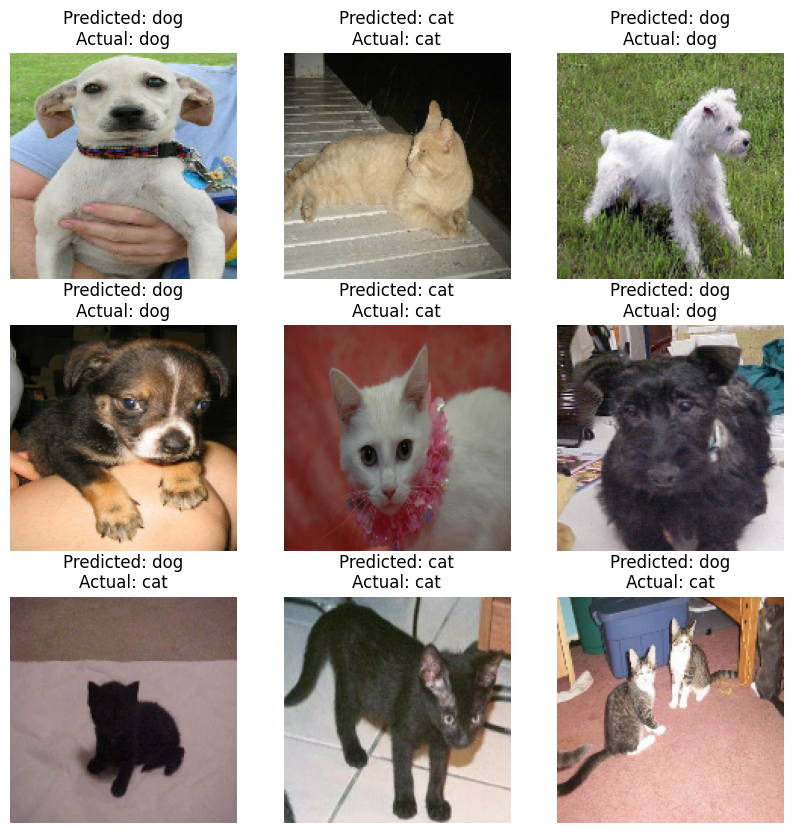

In [297]:
import matplotlib.pyplot as plt
import numpy as np

images_list = []
labels_list = []

for images, labels in test_ds:
    images_list.extend(images.numpy())
    labels_list.extend(labels.numpy())

images_list = np.array(images_list)
labels_list = np.array(labels_list)


plt.figure(figsize=(10,10))

for i in range(9):
    index = np.random.randint(len(images_list))

    plt.subplot(3,3,i+1)
    plt.imshow(images_list[index].astype("uint8"))

    plt.title(
        f"Predicted: {class_names[y_pred[index]]}\n"
        f"Actual: {class_names[labels_list[index]]}"
    )

    plt.axis("off")

plt.show()